# Análise de campanhas

Arquivos usados:
- `whatsapp_base_disparo_mascarado`
- `whatsapp_dim_telefone_mascarado`

## Parte 1 - Analise exploratória

1. Relacionar sistema de origem (`id_sistema_mask`) com status de disparos (`status_disparo`), com foco em taxa de entrega.

2. Avaliar o efeito da atualidade (`registro_data_atualizacao`) na taxa de sucesso.



### Importação de arquivos

In [1]:
# Bibliotecas e configurações iniciais

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [2]:
# Importação do arquivo Base Disparo

base_disparo = pd.read_parquet("whatsapp_base_disparo_mascarado")

print(base_disparo.shape)
base_disparo.head(3)

(392921, 16)


,id_conta,id_hsm,id_disparo,id_sessao,cpf,id_target,contato_telefone,categoria_hsm,ambiente,criacao_envio_datahora,envio_datahora,falha_datahora,descricao_falha,indicador_falha,id_status_disparo,status_disparo
0,-9142586270102516767,-7590735594542127444,-2317524427909960986,NaN,-5.220753e+18,9206664160911476254,2824089259510570290,Utilidade,prod,2025-10-07 13:14:53.037,2025-10-07 13:15:17.204,NaT,None,False,1,processing
1,-9142586270102516767,-3785213779161126614,-6855906542267037066,NaN,-7.869927e+18,6874603298726099113,-4599056651977889342,Utilidade,prod,2025-10-25 10:56:24.194,2025-10-25 10:56:45.028,NaT,None,False,1,processing
2,-9142586270102516767,-9203817354237048492,-4043820570593848035,NaN,5.192496e+18,-1874111216941729257,-1731551129526467355,Utilidade,prod,2025-10-29 11:04:14.987,2025-10-29 11:04:45.562,NaT,None,False,1,processing


In [3]:
# Importação do arquivo DIM Telefone

dim_telefone = pd.read_parquet("whatsapp_dim_telefone_mascarado")

print(dim_telefone.shape)
dim_telefone.head(3)

(283289, 11)


,telefone_ddi,telefone_ddd,telefone_numero,telefone_tipo,telefone_nacionalidade,telefone_qualidade,telefone_aparicoes,telefone_aparicoes_quantidade,telefone_proprietarios_quantidade,telefone_sistemas_quantidade,validacao_telefone
0,55,-1181433720517268842,-6862804366069381626,CELULAR,Brasil,VALIDO,"[{'id_sistema': '1257277410380486863', 'cpf': ...",1,1,1,"{'ddd_valido_br': True, 'formato_valido': True..."
1,55,-1181433720517268842,3856002700049294556,CELULAR,Brasil,VALIDO,"[{'id_sistema': '3094574413675758272', 'cpf': ...",1,1,1,"{'ddd_valido_br': True, 'formato_valido': True..."
2,55,-1181433720517268842,8067166217402075300,CELULAR,Brasil,VALIDO,"[{'id_sistema': '3094574413675758272', 'cpf': ...",1,1,1,"{'ddd_valido_br': True, 'formato_valido': True..."


### Checagem de qualidade dos dados

In [4]:
# Tipos de colunas

print('Tipos de coluna em base_disparo:')
display(base_disparo.dtypes)

print('Tipos de coluna em dim_telefone:')
display(dim_telefone.dtypes)

Tipos de coluna em base_disparo:


id_conta                           int64
id_hsm                             int64
id_disparo                         int64
id_sessao                        float64
cpf                              float64
id_target                          int64
contato_telefone                   int64
categoria_hsm                     object
ambiente                          object
criacao_envio_datahora    datetime64[us]
envio_datahora            datetime64[us]
falha_datahora            datetime64[us]
descricao_falha                   object
indicador_falha                     bool
id_status_disparo                  int64
status_disparo                    object
dtype: object

Tipos de coluna em dim_telefone:


telefone_ddi                         object
telefone_ddd                          int64
telefone_numero                       int64
telefone_tipo                        object
telefone_nacionalidade               object
telefone_qualidade                   object
telefone_aparicoes                   object
telefone_aparicoes_quantidade         int64
telefone_proprietarios_quantidade     int64
telefone_sistemas_quantidade          int64
validacao_telefone                   object
dtype: object

In [5]:
# Checagem de valores nulos

print('Nulos em base_disparo:')
display(base_disparo.isna().sum())

print('Nulos em dim_telefone:')
display(dim_telefone.isna().sum())

Nulos em base_disparo:


id_conta                       0
id_hsm                         0
id_disparo                     0
id_sessao                 156017
cpf                        31176
id_target                      0
contato_telefone               0
categoria_hsm                  0
ambiente                       0
criacao_envio_datahora         0
envio_datahora                 0
falha_datahora            365660
descricao_falha           365660
indicador_falha                0
id_status_disparo              0
status_disparo                 0
dtype: int64

Nulos em dim_telefone:


telefone_ddi                         0
telefone_ddd                         0
telefone_numero                      0
telefone_tipo                        0
telefone_nacionalidade               0
telefone_qualidade                   0
telefone_aparicoes                   0
telefone_aparicoes_quantidade        0
telefone_proprietarios_quantidade    0
telefone_sistemas_quantidade         0
validacao_telefone                   0
dtype: int64

In [6]:
# Status de disparo: importante para criar as taxas (entrega, falha etc)

print('Status de disparo:')
display(base_disparo['status_disparo'].value_counts(dropna=False).sort_values(ascending=False))

Status de disparo:


status_disparo
read          271566
delivered      85405
failed         27257
sent            5533
processing      3160
Name: count, dtype: int64

In [7]:
# Checagem de aparições
# Um telefone pode ter varias aparições, com sistema e data de atualização distintos

display(dim_telefone[dim_telefone['telefone_aparicoes_quantidade']>1][['telefone_numero','telefone_aparicoes', 'telefone_aparicoes_quantidade', 'telefone_qualidade']].head())

dim_telefone['telefone_aparicoes'][48708]

,telefone_numero,telefone_aparicoes,telefone_aparicoes_quantidade,telefone_qualidade
48708,8231373509248484653,"[{'id_sistema': '3094574413675758272', 'cpf': ...",2,VALIDO
48709,5580942104294601923,"[{'id_sistema': '3094574413675758272', 'cpf': ...",2,VALIDO
48710,-2610650737609854372,"[{'id_sistema': '1257277410380486863', 'cpf': ...",2,VALIDO
48711,-5777314259791929668,"[{'id_sistema': '3094574413675758272', 'cpf': ...",2,VALIDO
48712,-5232933994723894984,"[{'id_sistema': '1257277410380486863', 'cpf': ...",2,VALIDO


array([{'id_sistema': '3094574413675758272', 'cpf': 2851248869450150226, 'proprietario_tipo': 'CPF', 'registro_data_atualizacao': datetime.date(2025, 3, 22)},
       {'id_sistema': '4458959843028638627', 'cpf': 2851248869450150226, 'proprietario_tipo': 'CPF', 'registro_data_atualizacao': datetime.date(2025, 3, 22)}],
      dtype=object)

### Insights da EDA

- Insight 1: não há valores nulos nas chaves principais, logo, a taxa de entrega por sistema não será distorcida por perda de informação e a análise de atualidade é viável.

- Insight 2: o campo `telefone_aparicoes` precisa ser explodido e reduzido para 1 linha por `telefone_numero` + `id_sistema`, usando a data de atualização mais recente. Sem isso, o mesmo sistema pode ser contado várias vezes para o mesmo telefone e inflar os cálculos das taxas.

- Insight 3: podemos pensar em diferenças entre `taxa de entrega` (delivered) vs. `taxa de alcance` (delivered + read). Para regra de negócio, talvez seja interessante ver o alcance total, ou seja, incluindo aqueles usuários que também leram a mensagem.

### Tratamento dos dados

In [8]:
# Explode em telefone_aparicoes para pegar sistema e data de atualização

aparicoes = dim_telefone[
    ['telefone_numero', 'telefone_ddd', 'telefone_qualidade', 'telefone_aparicoes']
    ].explode('telefone_aparicoes')

aparicoes = aparicoes.dropna(subset=['telefone_aparicoes']).copy()

# Extrair o id_sistema em telefone_aparicoes
aparicoes['id_sistema_mask'] = aparicoes['telefone_aparicoes'].apply(
    lambda x: str(x.get('id_sistema')) if isinstance(x, dict) else np.nan
)

# Extrair a data de atualizacao em telefone_aparicoes
aparicoes['registro_data_atualizacao'] = pd.to_datetime(
    aparicoes['telefone_aparicoes'].apply(
        lambda x: x.get('registro_data_atualizacao') if isinstance(x, dict) else pd.NaT
    ),
    errors='coerce'
)

In [9]:
# Visualização de quantidade de linhas explodidas e sistemas encontrados

print(f"Explode gerou {len(aparicoes)} linhas.")

print('\nSistemas encontrados em telefone_aparicoes:')
display(aparicoes['id_sistema_mask'].value_counts(dropna=False))

Explode gerou 1529772 linhas.

Sistemas encontrados em telefone_aparicoes:


id_sistema_mask
-133612832286195827     597199
3094574413675758272     437705
1257277410380486863     320927
-4704067261970591609    135613
4458959843028638627      32520
-2757366171786647144      5808
Name: count, dtype: int64

In [10]:
# Preparação para a base final de análise

# Evitar duplicidade: consolidar por telefone + sistema e manter a data mais recente
dim_por_sistema = (
    aparicoes.groupby(['telefone_numero', 'id_sistema_mask'], as_index=False)
    .agg(
        registro_data_atualizacao=('registro_data_atualizacao', 'max'),
        telefone_ddd=('telefone_ddd', 'first'),
        telefone_qualidade=('telefone_qualidade', 'first')
    )
)

In [11]:
# Merge dos dados: contato_telefone ~~ telefone_numero
df = base_disparo.merge(
    dim_por_sistema,
    left_on='contato_telefone',
    right_on='telefone_numero',
    how='left'
)

# Ajuste: ficar apenas com id_sistema_mask não nulo

df = df[df['id_sistema_mask'].notnull()]
print(df.shape)
df.head()

(748683, 21)


,id_conta,id_hsm,id_disparo,id_sessao,cpf,id_target,contato_telefone,categoria_hsm,ambiente,criacao_envio_datahora,envio_datahora,falha_datahora,descricao_falha,indicador_falha,id_status_disparo,status_disparo,telefone_numero,id_sistema_mask,registro_data_atualizacao,telefone_ddd,telefone_qualidade
1,-9142586270102516767,-3785213779161126614,-6855906542267037066,NaN,-7.869927e+18,6874603298726099113,-4599056651977889342,Utilidade,prod,2025-10-25 10:56:24.194,2025-10-25 10:56:45.028,NaT,None,False,1,processing,-4.599057e+18,-133612832286195827,NaT,-1.181434e+18,VALIDO
2,-9142586270102516767,-3785213779161126614,-6855906542267037066,NaN,-7.869927e+18,6874603298726099113,-4599056651977889342,Utilidade,prod,2025-10-25 10:56:24.194,2025-10-25 10:56:45.028,NaT,None,False,1,processing,-4.599057e+18,3094574413675758272,2024-05-16,-1.181434e+18,VALIDO
4,-9142586270102516767,-3785213779161126614,-3867536685401812059,NaN,-6.716780e+18,2633882497346372274,-5478890758772712776,Utilidade,prod,2025-11-01 08:31:00.489,2025-11-01 08:31:14.661,NaT,None,False,1,processing,-5.478891e+18,3094574413675758272,2024-11-29,-1.181434e+18,VALIDO
5,-9142586270102516767,-3785213779161126614,-1014974390614404669,NaN,7.845383e+18,-7448118375290831604,2224533453719573633,Utilidade,prod,2025-11-01 08:30:58.679,2025-11-01 08:31:18.792,NaT,None,False,1,processing,2.224533e+18,1257277410380486863,2023-10-18,-1.929277e+18,VALIDO
6,-9142586270102516767,-3785213779161126614,-1014974390614404669,NaN,7.845383e+18,-7448118375290831604,2224533453719573633,Utilidade,prod,2025-11-01 08:30:58.679,2025-11-01 08:31:18.792,NaT,None,False,1,processing,2.224533e+18,3094574413675758272,2025-01-22,-1.929277e+18,VALIDO


In [12]:
# Criar flags para cada status de disparo 

df['flag_entrega'] = (df['status_disparo']=='delivered').astype(int)

df['flag_alcance'] = (df['status_disparo'].isin(['delivered', 'read'])).astype(int)

df['flag_falha'] = (df['status_disparo']=='failed').astype(int)

# Calcular dias entre a última atualização e o envio

df['dias_desde_atualizacao'] = (
    df['envio_datahora'].dt.normalize() - df['registro_data_atualizacao']
).dt.days

### Parte 1.1 - Taxa de entrega por sistema de origem

In [13]:

# Agregar taxas por sistema de origem
# Onde: taxa_entrega = delivered, taxa alcance = delivered + read

resumo_sistema = (
    df.dropna(subset=['id_sistema_mask'])
           .groupby('id_sistema_mask')
           .agg(
               tentativas=('id_disparo', 'count'),
               telefones_unicos=('contato_telefone', 'nunique'),
               cpfs_unicos=('cpf', 'nunique'),
               taxa_entrega=('flag_entrega', 'mean'),
               taxa_alcance=('flag_alcance', 'mean'),
               taxa_falha=('flag_falha', 'mean'),
               media_dias=('dias_desde_atualizacao', 'mean'),
               mediana_dias=('dias_desde_atualizacao', 'median'),
           )
           .round(4)
           .sort_values(['taxa_entrega', 'tentativas'], ascending=[False, False])
           .reset_index()
)

resumo_sistema


,id_sistema_mask,tentativas,telefones_unicos,cpfs_unicos,taxa_entrega,taxa_alcance,taxa_falha,media_dias,mediana_dias
0,-2757366171786647144,6829,4680,4077,0.2773,0.9606,0.0236,297.2557,303.0
1,1257277410380486863,170393,122919,117138,0.2362,0.9411,0.0412,749.0944,478.0
2,4458959843028638627,19781,11770,12737,0.2333,0.9484,0.0275,306.5697,298.0
3,-4704067261970591609,197224,135268,140223,0.2148,0.9892,0.0026,130.2103,147.0
4,3094574413675758272,243854,175517,174545,0.2111,0.9494,0.0321,292.6413,153.0
5,-133612832286195827,110602,81348,78333,0.2053,0.9229,0.0600,1086.3525,839.0


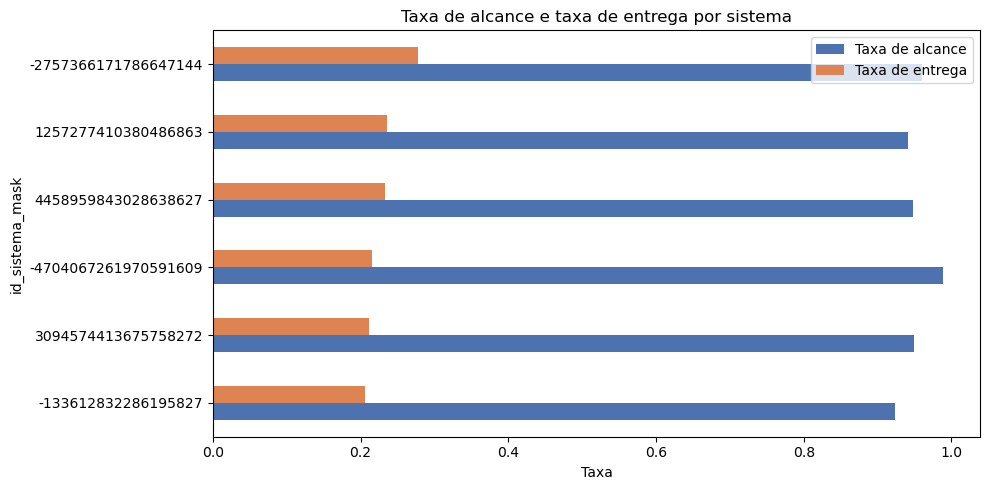

In [14]:
# Visualização - taxa de entrega e de alcance por sistema

ax = resumo_sistema.sort_values('taxa_entrega').plot(
    x='id_sistema_mask',
    y=['taxa_alcance', 'taxa_entrega'],
    kind='barh',
    figsize=(10, 5),
    title='Taxa de alcance e taxa de entrega por sistema',
    color=['#4C72B0', '#DD8452']
)

ax.set_xlabel('Taxa')
ax.set_ylabel('id_sistema_mask')
ax.legend(['Taxa de alcance', 'Taxa de entrega'])
plt.tight_layout()
plt.show()

- O sistema `-2757366171786647144` tem a maior taxa de entrega (27%).
- Já o sistema `-4704067261970591609` tem a maior taxa de alcance (98%).

###  Parte 1.2 - Janela de atualidade (decaimento)

Vamos separar os dias entre a atualização do número e a entrega da msg em faixas entre 0 e +730 dias. A ideia é ver se a data entre a última atualização impacta no sucesso dos disparos.

In [15]:
# Parte 1.2 - Janela de atualidade (decaimento)

base_dias = df[df['dias_desde_atualizacao'].notna()].copy()

bins = [-1, 30, 90, 180, 365, 730, 9999]
labels = ['0-30d', '31-90d', '91-180d', '181-365d', '366-730d', '+730d']

base_dias['faixa_atualizacao_dias'] = pd.cut(
    base_dias['dias_desde_atualizacao'],
    bins=bins,
    labels=labels
)

resumo_faixa = (
    base_dias.groupby('faixa_atualizacao_dias', observed=True)
              .agg(
                  tentativas=('id_disparo', 'count'),
                  taxa_alcance=('flag_alcance', 'mean'),
                  taxa_falha=('flag_falha', 'mean')
              )
              .round(4)
              .reset_index()
)

resumo_faixa

,faixa_atualizacao_dias,tentativas,taxa_alcance,taxa_falha
0,0-30d,7714,0.9754,0.0097
1,31-90d,33096,0.9702,0.0156
2,91-180d,307061,0.9815,0.0090
3,181-365d,111869,0.9424,0.0344
4,366-730d,98040,0.9341,0.0431
5,+730d,79896,0.9286,0.0546


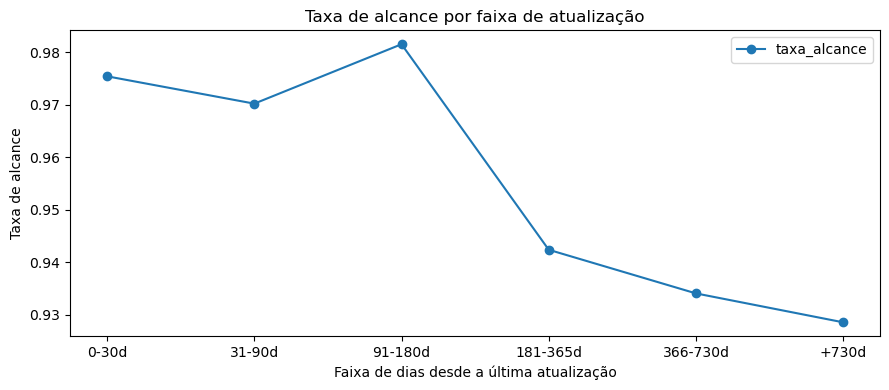

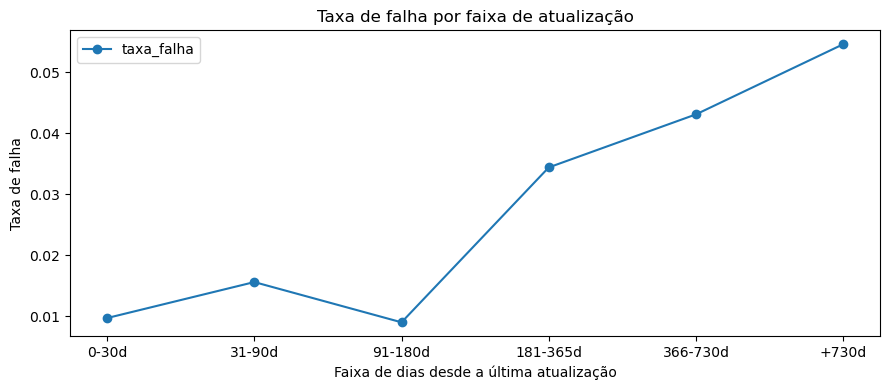

In [16]:
figsize = (9, 4)

ax = resumo_faixa.plot(
    x='faixa_atualizacao_dias',
    y='taxa_alcance',
    marker='o',
    figsize=figsize,
    title='Taxa de alcance por faixa de atualização'
)
ax.set_xlabel('Faixa de dias desde a última atualização')
ax.set_ylabel('Taxa de alcance')
plt.tight_layout()
plt.show()

ax = resumo_faixa.plot(
    x='faixa_atualizacao_dias',
    y='taxa_falha',
    marker='o',
    figsize=figsize,
    title='Taxa de falha por faixa de atualização'
)
ax.set_xlabel('Faixa de dias desde a última atualização')
ax.set_ylabel('Taxa de falha')
plt.tight_layout()
plt.show()


- Quanto maior a quantidade de dias desde a última atualização, menor é a taxa de alcance, o que prejudica o sucesso do disparo.

### Conclusões da Parte 1

1. Existem diferenças clara entre os sistemas quando medimos taxa de entrega e taxa de alcance.

    - O sistema `2757366171786647144` apresenta a maior taxa de entrega na amostra analisada. Já o sistema `-4704067261970591609` possui a maior taxa de alcance.
    - O sistema `-133612832286195827` apresenta as piores taxas de entrega e de alcance. Esse sistema também aparece com telefones mais antigos, em média.
    - Vale ressaltar que o sistema `-2757366171786647144` tem bom desempenho com volume muito menor de tentativas, enquanto o sistema `-4704067261970591609` precisou de maior número de tentativas.

2. Atualidade importa: quanto menos recente a atualização do telefone, menor tende a ser a chance de sucesso, indicando decaimento de qualidade ao longo do tempo.
    - Existe um prazo de validade prático para telefone "quente", com melhor desempenho nas faixas mais recentes de atualização, sendo esse prazo em torno de até 180 dias.

3. Parte da diferença observada entre as fontes pode estar ligada a **viés de seleção**, porque algumas bases aparecem muito mais no histórico do que outras.
    - Volume não pode ser confundido com qualidade: a leitura correta combina a taxa de entrega e qtde de tentativas.

4. Por fim, o "calor" do telefone depende ao mesmo tempo de duas dimensões: confiabilidade histórica da origem e tmepo desde a última atualização. Isso prepara diretamente a regra de score da Parte 2.


## Parte 2 - Inteligência de Priorização 

Implementar um ranking e algoritmo com base nas conclusões da Parte 1:

- sistemas de origem tem confiabilidades diferentes;
- atualidade do cadastro impacta o sucesso (decaimento);
- volume deve ser tratado para evitar supervalorizar bases pequenas.


In [17]:
# Vies de seleção: volume de tentativas pode inflar performances



### Parte 2.1 - Ranking de sistema

Construir um score de confiabilidade por sistema que leve em conta:

1. score_origem: taxa histórica de sucesso do sistema, ponderada por volume (com suavização bayesiana);
2. score_atualidade: a atualidade dos registros (um sistema pode performar bem, mas com base muito antiga).

`Score sistema = 100 * score_origem * score_atualidade`

**Disclaimer:** Definimos sucesso como o alcance aos usuários (delivered + read), mas isso pode ser ajustado de acordo com a regra de negócio desejada.

In [18]:
# Definir parâmetro da suaviazação bayesiana com base nas tentativas

df.groupby('id_sistema_mask')['id_disparo'].count().describe()

count         6.000000
mean     124780.500000
std       96587.308137
min        6829.000000
25%       42486.250000
50%      140497.500000
75%      190516.250000
max      243854.000000
Name: id_disparo, dtype: float64

In [19]:
# Score origem

df['sucesso_origem'] = df['flag_alcance'].astype('int64')

ranking_sistemas = (
    df.groupby('id_sistema_mask', as_index=False)
    .agg(
        tentativas=('id_disparo', 'count'),
        sucessos=('sucesso_origem', 'sum'),
        taxa_sucesso=('sucesso_origem', 'mean'),
        mediana_dias=('dias_desde_atualizacao', 'median'),
        media_dias=('dias_desde_atualizacao', 'mean')
    )
)

ranking_sistemas

,id_sistema_mask,tentativas,sucessos,taxa_sucesso,mediana_dias,media_dias
0,-133612832286195827,110602,102076,0.922913,839.0,1086.352517
1,-2757366171786647144,6829,6560,0.960609,303.0,297.255674
2,-4704067261970591609,197224,195092,0.989190,147.0,130.210309
3,1257277410380486863,170393,160364,0.941142,478.0,749.094371
4,3094574413675758272,243854,231506,0.949363,153.0,292.641330
5,4458959843028638627,19781,18760,0.948385,298.0,306.569739


In [20]:
# Suavização bayesiana para reduzir volatilidade de sistemas com baixo volume

taxa_global = df['sucesso_origem'].mean()
prior = 6000 # força de suavização

ranking_sistemas['score_origem'] = (
    ranking_sistemas['sucessos'] + taxa_global * prior
) / (
    ranking_sistemas['tentativas'] + prior
)

In [21]:
# Fator de recencia: sem penalizar ate 180 dias; depois decai por meia-vida anual

ranking_sistemas['score_atualidade'] = np.where(
    ranking_sistemas['mediana_dias'] <= 180,
    1.0,
    np.exp(-np.log(2) * (ranking_sistemas['mediana_dias'] - 180) / 365)
)

In [22]:
# Score final da origem na escala [0, 100]
ranking_sistemas['score_sistema'] = (
    100
    * ranking_sistemas['score_origem']       # suavização bayesiana
    * ranking_sistemas['score_atualidade']   # fator de recencia
)

# Ordenacao final do ranking
ranking_sistemas = ranking_sistemas.sort_values(
    ['score_sistema', 'tentativas'],
    ascending=[False, False]
).reset_index(drop=True)

ranking_sistemas['rank_origem'] = ranking_sistemas.index + 1

ranking_sistemas['classe_confiabilidade'] = pd.qcut(
    ranking_sistemas['score_sistema'],
    q=3,
    labels=['Baixa', 'Media', 'Alta']
)

ranking_sistemas[
    [
        'rank_origem',
        'id_sistema_mask',
        'tentativas',
        'taxa_sucesso',
        'mediana_dias',
        'score_origem',
        'score_atualidade',
        'score_sistema',
        'classe_confiabilidade'
    ]
]

,rank_origem,id_sistema_mask,tentativas,taxa_sucesso,mediana_dias,score_origem,score_atualidade,score_sistema,classe_confiabilidade
0,1,-4704067261970591609,197224,0.989190,147.0,0.988156,1.000000,98.815552,Alta
1,2,3094574413675758272,243854,0.949363,153.0,0.949478,1.000000,94.947816,Alta
2,3,4458959843028638627,19781,0.948385,298.0,0.949727,0.799246,75.906609,Media
3,4,-2757366171786647144,6829,0.960609,303.0,0.957590,0.791693,75.811735,Media
4,5,1257277410380486863,170393,0.941142,478.0,0.941585,0.567842,53.467130,Baixa
5,6,-133612832286195827,110602,0.922913,839.0,0.924520,0.286086,26.449227,Baixa


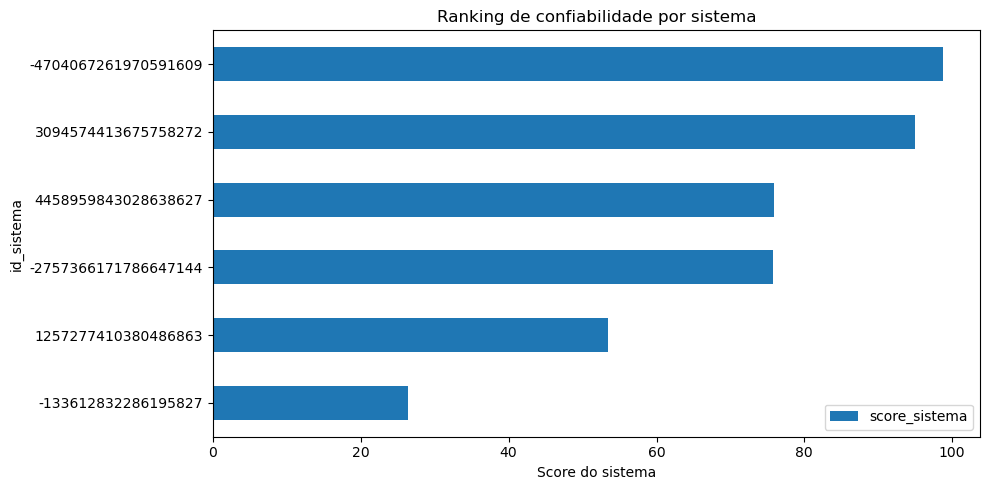

In [23]:

ax = ranking_sistemas.sort_values('score_sistema').plot(
    x='id_sistema_mask',
    y='score_sistema',
    kind='barh',
    figsize=(10, 5),
    title='Ranking de confiabilidade por sistema'
)
ax.set_xlabel('Score do sistema')
ax.set_ylabel('id_sistema')
plt.tight_layout()
plt.show()



#### Por que o sistema X é melhor que o Y?

Porque ele combina melhor os **três componentes do score**:

1. **taxa ajustada de sucesso** maior;
2. **volume** suficiente para sustentar essa taxa;
3. **recência típica** melhor.

Exemplo:
- o sistema `-4704067261970591609` fica no topo porque une **taxa ajustada muito alta** com **recência mediana baixa**;
- o sistema `-133612832286195827` cai para o fim porque, embora tenha muito volume, seus registros estão **bem mais envelhecidos**, o que reduz o fator de recência.

Ou seja, o ranking não premia apenas “quem acerta mais”, mas “quem acerta mais de forma robusta e com base mais quente”.


### Parte 2.2 - Algoritmo de escolha

Além do fator de confiabilidade do sistema de origem e da atualidade dos registros telefônicos, no algoritmo final podemos incluir ainda o DDD e a qualidade do telefone.

In [ ]:

# Qualidade do telefone

df.groupby('telefone_qualidade').agg(
    tentativas=('id_disparo', 'count'),
    taxa_sucesso=('flag_alcance', 'mean')
).round(4).sort_values('tentativas', ascending=False)


,tentativas,taxa_sucesso
telefone_qualidade,,
VALIDO,593504,0.9521
SUSPEITO,153329,0.9635
INVALIDO,1850,0.8281
